# N2 · 冻结策略消融 (Freezing Ablation)

> 配套 10.3-L2 · 用 `set_freeze` 对比「冻 LLM 只训连接器」vs「全解冻」, 看可训练参数量 vs 最终准确率。
> 这是 VLM 训练最经典的一个消融 (接 9.4 实验设计)。

In [1]:
import sys
from pathlib import Path
SRC = Path.cwd().parent / "src"
sys.path.insert(0, str(SRC))
import torch, numpy as np
import mini_vlm as mv
print('就绪')

就绪


## 1. 三种冻结策略, 同数据同训练步数 (公平对照, 9.4-L3)

In [2]:
X, y, n_patch = mv.make_vqa_dataset(n_classes=4, n_per_class=16, seed=1)
configs = {
    "全解冻 (连接器+视觉塔+LLM)": dict(freeze_vision=False, freeze_llm=False),
    "冻视觉塔 (连接器+LLM)":       dict(freeze_vision=True,  freeze_llm=False),
    "只训连接器 (冻视觉塔+LLM)":   dict(freeze_vision=True,  freeze_llm=True),
}
results = []
for name, fz in configs.items():
    torch.manual_seed(0)   # 同初始化 (公平)
    m = mv.build_mini_vlm(patch_dim=X.shape[2], n_patch=n_patch, n_classes=4)
    mv.set_freeze(m, **fz)
    n_train = mv.count_trainable(m)
    loss, acc = mv.train_mini_vlm(m, X, y, epochs=40, lr=5e-3)
    results.append({"策略": name, "可训练参数": n_train, "最终准确率": round(acc[-1], 2)})
    print(f"  {name:28} 参数 {n_train:>6}  acc {acc[-1]:.2f}")

  全解冻 (连接器+视觉塔+LLM)            参数  25332  acc 1.00


  冻视觉塔 (连接器+LLM)               参数  19140  acc 1.00


  只训连接器 (冻视觉塔+LLM)             参数   1988  acc 1.00


## 2. 可视化: 参数量 vs 准确率的权衡

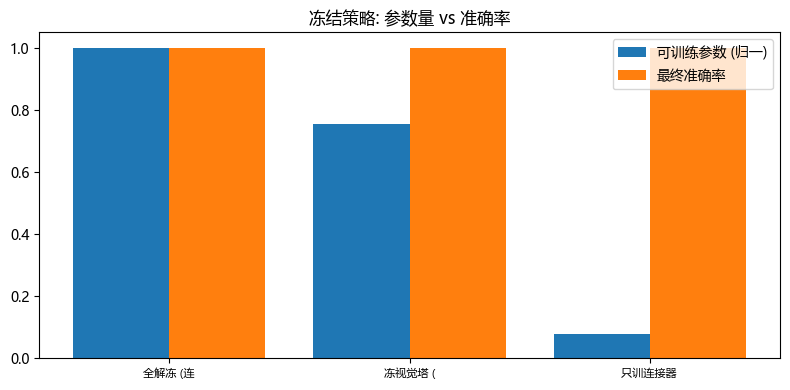

,策略,可训练参数,最终准确率
0,全解冻 (连接器+视觉塔+LLM),25332,1.0
1,冻视觉塔 (连接器+LLM),19140,1.0
2,只训连接器 (冻视觉塔+LLM),1988,1.0


In [3]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
import pandas as pd
df = pd.DataFrame(results)
fig, ax = plt.subplots(figsize=(8,4))
x = range(len(df))
ax.bar([i-0.2 for i in x], df["可训练参数"]/df["可训练参数"].max(), 0.4, label='可训练参数 (归一)')
ax.bar([i+0.2 for i in x], df["最终准确率"], 0.4, label='最终准确率')
ax.set_xticks(list(x)); ax.set_xticklabels([s[:6] for s in df["策略"]], fontsize=8)
ax.legend(); ax.set_title('冻结策略: 参数量 vs 准确率')
plt.tight_layout(); plt.show()
df

## 3. 解读 (接 9.4)

- **只训连接器**: 参数最少 (差几个数量级), 但在这个简单合成任务上仍可能学好 —— 因为连接器足以传递类别信息。
- **全解冻**: 参数最多, 灵活性最高, 但真实场景更易过拟合/遗忘 (L4)。
- 真实 VLM 的权衡 (L2): 默认**先全冻只训连接器** (省稳), 再视情况解冻 LLM。

> 这正是 9.4 说的: 架构/训练选择是有**约束**的决定。「冻 vs 解冻」没有绝对答案,
> 取决于任务难度、数据量、算力。这个消融让你亲手看到权衡的形状。

In [4]:
print("VLM 冻结策略心法 (L2):")
print("  · 连接器: 永远训 (唯一必须从头学的桥)")
print("  · 视觉塔: 默认全程冻 (表示已够好, 训它贵且可能毁对齐)")
print("  · LLM: 阶段1冻(护语言) → 阶段2解冻(学用视觉) → 用 LoRA 抗遗忘")
print("  · 原则: 能冻就冻、逐步解冻")

VLM 冻结策略心法 (L2):
  · 连接器: 永远训 (唯一必须从头学的桥)
  · 视觉塔: 默认全程冻 (表示已够好, 训它贵且可能毁对齐)
  · LLM: 阶段1冻(护语言) → 阶段2解冻(学用视觉) → 用 LoRA 抗遗忘
  · 原则: 能冻就冻、逐步解冻


## 4. 反思 (10.3 收口)

你做了一次 VLM 冻结策略消融, 看到了「参数量 vs 效果」的权衡。带走:
- 两阶段配方 (L1) + 数据/冻结 (L2) + LLaVA 配方 (L3) + 避坑 (L4) = 训出一个 VLM。
- 冻结策略是最经典的 VLM 消融; 默认能冻就冻。
- 你现在能端到端训一个 mini-VLM 并诊断它 (N1) + 做冻结消融 (N2)。

> 交棒 10.4: VLM 会「读」图了, 但怎么让它「画」图? 把图变成离散 token (VQ),
> 像生成文本一样自回归生成视觉 token —— 下一专题 `visual-tokenization-generation`。